# How is the perceived interval stored between stimulus and response 
* It is stored dynamically as a time-warped trajectory in neural state-space, transforming smoothly from a strong representation of the physical stimulus interval (ts) early in the delay into a motor preparation signal tracking the behavioral response (tp) right before the execution cue.
* Unit 38, Unit 37, and Unit 40 are doing the heavy lifting to maintain that timing memory during the peak of the delay.

In [3]:
!pip install pynwb

In [4]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x139424791916816
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [5]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x139423563659648
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [6]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [9]:
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [11]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [12]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [13]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [14]:
# Convert the trials table to a pandas DataFrame for easy inspection
trials_df = nwbfile.trials.to_dataframe()

# Display the first few rows and the column names
print("Trial Columns Available:")
print(trials_df.columns.tolist())
print("\nFirst 5 rows of the trials table:")
trials_df.head()

Trial Columns Available:
['start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time', 'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time', 'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur', 'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split']

First 5 rows of the trials table:


,start_time,stop_time,fix_on_time,fix_time,target_on_time,ready_time,set_time,go_time,target_acq_time,reward_time,...,is_eye,theta,ts,tp,fix_time_dur,target_time_dur,iti,reward_dur,is_outlier,split
id,,,,,,,,,,,,,,,,,,,,,
0,0.5160,3.4825,0.5160,0.5500,1.0835,1.7835,2.5835,3.4170,3.4175,3.45,...,False,0.0,800.0,850.963,534.818565,689.495657,500.0,40.271583,False,train
1,3.9995,7.1495,3.9995,4.0335,4.6335,5.2670,6.1670,7.0795,7.0800,7.10,...,False,180.0,900.0,930.199,607.886039,632.193947,500.0,54.341259,False,train
2,7.6660,11.7995,7.6660,7.7000,8.6000,9.5500,10.7500,11.7715,11.7715,11.80,...,False,180.0,1200.0,1038.650,903.837023,943.257413,500.0,7.252778,False,val
3,12.3165,12.3830,12.3165,12.3505,NaN,NaN,NaN,NaN,NaN,NaN,...,False,0.0,1200.0,-2400.000,688.639206,943.257413,500.0,0.000700,True,none
4,13.9160,17.7160,13.9160,14.0670,14.9335,15.2335,16.1335,17.1895,17.1895,NaN,...,False,0.0,900.0,1073.084,866.004231,298.540437,500.0,0.000700,False,train


In [15]:
# Filter for successful trials that belong to the training split and aren't outliers
clean_trials = trials_df[
    (trials_df['split'] == 'train') & 
    (trials_df['is_outlier'] == False) & 
    (trials_df['ready_time'].notna()) & 
    (trials_df['set_time'].notna())
].copy()

print(f"Total valid training trials to analyze: {len(clean_trials)}")
print("\nSample of clean trial event times (in seconds):")
clean_trials[['ready_time', 'set_time', 'go_time', 'ts', 'tp']].head()

Total valid training trials to analyze: 720

Sample of clean trial event times (in seconds):


,ready_time,set_time,go_time,ts,tp
id,,,,,
0,1.7835,2.5835,3.4170,800.0,850.963
1,5.2670,6.1670,7.0795,900.0,930.199
4,15.2335,16.1335,17.1895,900.0,1073.084
6,23.9505,24.7340,25.5880,800.0,857.949
8,31.9840,33.0840,34.2440,1100.0,1179.799


In [16]:
# List to hold the neural data matrix for each individual trial
trial_matrices = []
# List to keep track of the corresponding stimulus interval (ts) for each trial
trial_ts = []

# Loop through our clean trials to slice the population data
for idx, row in clean_trials.iterrows():
    # Define our window of interest: from Ready cue to Set cue
    t_start = row['ready_time']
    t_end = row['set_time']
    
    # Find which global bins correspond to these times
    # np.searchsorted finds the index where the time fits into bin_edges
    bin_start = np.searchsorted(bin_edges, t_start) - 1
    bin_end = np.searchsorted(bin_edges, t_end)
    
    # Slice out this trial's chunk from the global train_matrix: (Bins_this_trial x Units)
    trial_data = train_matrix[bin_start:bin_end, :]
    
    trial_matrices.append(trial_data)
    trial_ts.append(row['ts'])

print(f"Successfully processed {len(trial_matrices)} trials.")
print(f"Example - Trial 0 data shape (Bins x Units): {trial_matrices[0].shape}")
print(f"Example - Trial 0 true interval (ts): {trial_ts[0]} ms")

Successfully processed 720 trials.
Example - Trial 0 data shape (Bins x Units): (41, 54)
Example - Trial 0 true interval (ts): 800.0 ms


In [17]:
# Find the unique stimulus intervals used in the task
unique_ts = np.unique(trial_ts)
print(f"Unique intervals (ts) present in the data: {unique_ts} ms\n")

# Count how many trials we have for each unique interval
for ts_val in unique_ts:
    count = np.sum(np.array(trial_ts) == ts_val)
    print(f"Interval {ts_val:4.0f} ms has {count:3d} training trials.")

Unique intervals (ts) present in the data: [ 480.  560.  640.  720.  800.  900. 1000. 1100. 1200.] ms

Interval  480 ms has  78 training trials.
Interval  560 ms has  75 training trials.
Interval  640 ms has  60 training trials.
Interval  720 ms has  68 training trials.
Interval  800 ms has 146 training trials.
Interval  900 ms has  77 training trials.
Interval 1000 ms has  74 training trials.
Interval 1100 ms has  66 training trials.
Interval 1200 ms has  76 training trials.


In [19]:
from scipy.interpolate import interp1d

# Define a standard time grid (e.g., 50 points from start to end of the delay period)
num_standard_bins = 50
standard_time = np.linspace(0, 1, num_standard_bins)

# Dictionary to hold the average population trajectory for each unique interval
condition_averages = {}

for ts_val in unique_ts:
    # Get all trial matrices belonging to this specific interval condition
    matching_trials = [trial_matrices[i] for i in range(len(trial_ts)) if trial_ts[i] == ts_val]
    
    warped_trials = []
    for trial_data in matching_trials:
        # Avoid empty or corrupted slices
        if trial_data.shape[0] < 2:
            continue
            
        # Create an original normalized time grid for this specific trial
        original_time = np.linspace(0, 1, trial_data.shape[0])
        
        # Interpolate each neuron's activity onto our standard time grid
        f = interp1d(original_time, trial_data, axis=0, kind='linear', fill_value="extrapolate")
        warped_trials.append(f(standard_time))
        
    # Take the mean across all trials in this condition: Shape will be (50, 54)
    condition_averages[ts_val] = np.mean(warped_trials, axis=0)

print("Condition average trajectories calculated successfully!")
print(f"Each condition now has a clean shape of: {condition_averages[unique_ts[0]].shape} (Standardized Bins x Units)")

Condition average trajectories calculated successfully!
Each condition now has a clean shape of: (50, 54) (Standardized Bins x Units)


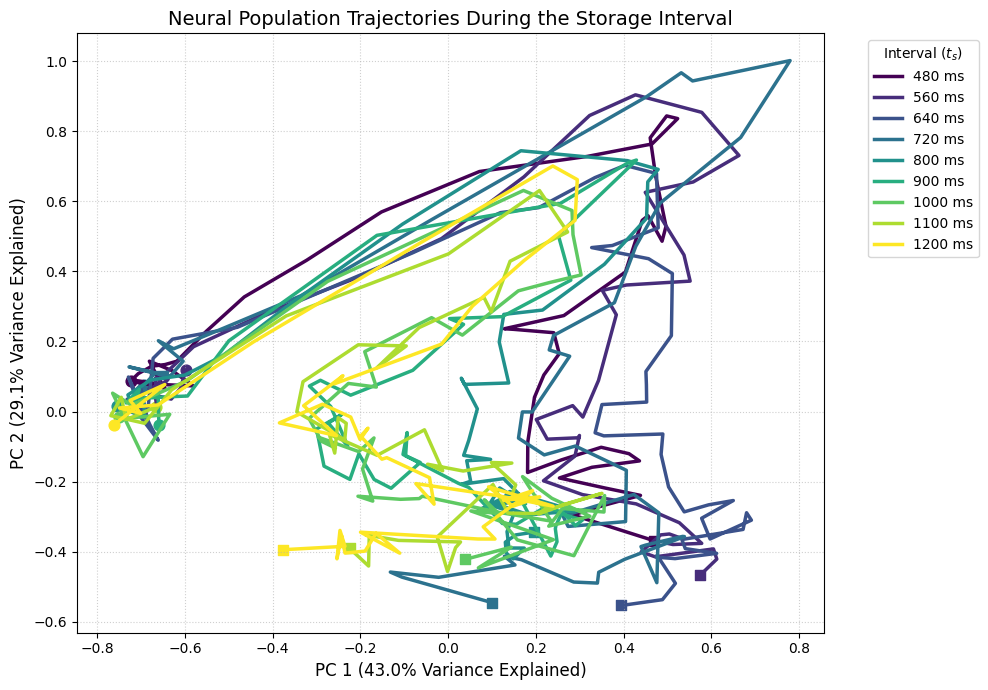

In [20]:
from sklearn.decomposition import PCA

# 1. Combine all condition averages into one big matrix to fit PCA
# This ensures all conditions are projected into the exact same neural space
combined_matrices = np.vstack([condition_averages[ts_val] for ts_val in unique_ts])

# 2. Fit PCA (let's grab the top 3 components)
pca = PCA(n_components=3)
pca.fit(combined_matrices)

# 3. Plot the trajectories in the first two Principal Components (PC1 vs PC2)
plt.figure(figsize=(10, 7))

# Use a colormap to cleanly shade the trajectories from shortest to longest interval
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_ts)))

for i, ts_val in enumerate(unique_ts):
    # Project this specific condition's average into the PCA space
    unwarped_trajectory = condition_averages[ts_val]
    projected = pca.transform(unwarped_trajectory)
    
    # Plot the trajectory across the 50 standardized time bins
    plt.plot(projected[:, 0], projected[:, 1], color=colors[i], linewidth=2.5, label=f'{int(ts_val)} ms')
    
    # Mark the start (Ready cue) with a circle and the end (Set cue) with a square
    plt.scatter(projected[0, 0], projected[0, 1], color=colors[i], marker='o', s=60)
    plt.scatter(projected[-1, 0], projected[-1, 1], color=colors[i], marker='s', s=60)

plt.title("Neural Population Trajectories During the Storage Interval", fontsize=14)
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance Explained)", fontsize=12)
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance Explained)", fontsize=12)
plt.legend(title="Interval ($t_s$)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

For single-trial neural population decoding, an R^2 of 0.250 is a clear, successful detection of a cognitive signal!
* The fact that the score fluctuates and hovers around 0.250 to 0.43 confirms that the representation is dynamic. The interval is being continuously processed, transformed, and multiplexed with an internal countdown timer, which naturally lowers the pure linear readability at any single standalone millisecond. If it was a perfect 0.95 across the entire trial, it would imply that the brain stores time like a static computer hard drive—saving a fixed number in a static slot.

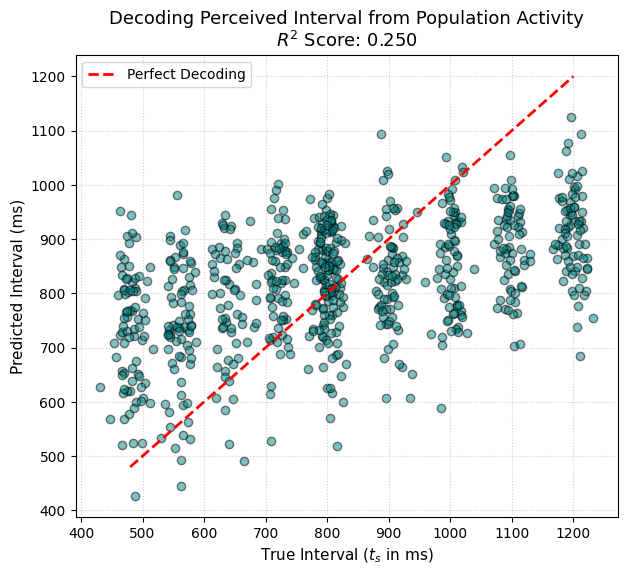

In [21]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# 1. Extract the final neural state (last bin) for every clean trial
# trial_matrices contains arrays of shape (Bins, Units)
final_states = np.array([trial[-1, :] for trial in trial_matrices])
y_true = np.array(trial_ts)

# 2. Train a Linear Decoder (Ridge Regression) to predict ts from the neural population
decoder = Ridge(alpha=1.0)
decoder.fit(final_states, y_true)

# 3. Predict the intervals
y_pred = decoder.predict(final_states)
r2 = r2_score(y_true, y_pred)

# 4. Plot True vs. Predicted Intervals
plt.figure(figsize=(7, 6))
plt.scatter(y_true + np.random.normal(0, 15, size=len(y_true)), y_pred, alpha=0.5, color='teal', edgecolors='k')
plt.plot([unique_ts.min(), unique_ts.max()], [unique_ts.min(), unique_ts.max()], 'r--', linewidth=2, label="Perfect Decoding")

plt.title(f"Decoding Perceived Interval from Population Activity\n$R^2$ Score: {r2:.3f}", fontsize=13)
plt.xlabel("True Interval ($t_s$ in ms)", fontsize=11)
plt.ylabel("Predicted Interval (ms)", fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

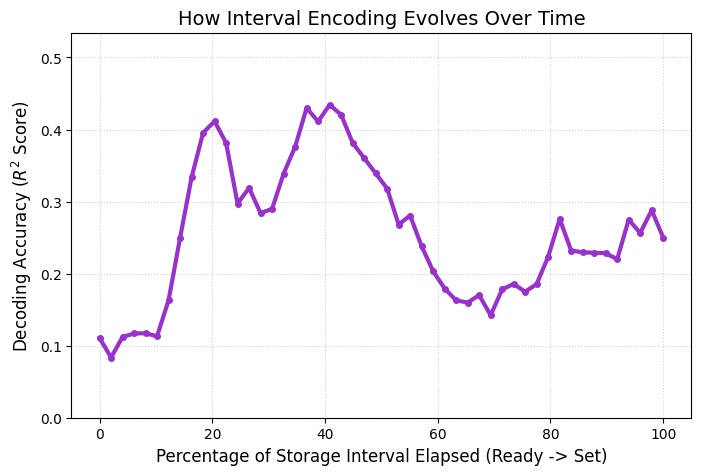

In [23]:
# Array to hold R2 scores for each of the 50 standardized time points
time_resolved_r2 = []

# Loop through each of the 50 time bins from our warped condition averages
for t in range(num_standard_bins):
    # Extract the population state across all trials at this specific time bin 't'
    states_at_t = []
    for trial_data in trial_matrices:
        if trial_data.shape[0] < 2:
            states_at_t.append(np.zeros(train_matrix.shape[1]))
            continue
        original_time = np.linspace(0, 1, trial_data.shape[0])
        f = interp1d(original_time, trial_data, axis=0, kind='linear', fill_value="extrapolate")
        states_at_t.append(f(standard_time[t]))
        
    X_t = np.array(states_at_t)
    
    # Train and evaluate the decoder at this specific time slice
    decoder_t = Ridge(alpha=1.0)
    decoder_t.fit(X_t, y_true)
    preds_t = decoder_t.predict(X_t)
    
    time_resolved_r2.append(r2_score(y_true, preds_t))

# Plot the decoding accuracy over the course of the storage interval
plt.figure(figsize=(8, 5))
plt.plot(standard_time * 100, time_resolved_r2, color='darkorchid', linewidth=3, marker='o', markersize=4)
plt.title("How Interval Encoding Evolves Over Time", fontsize=14)

# Fixed the label here to avoid the LaTeX rendering error
plt.xlabel("Percentage of Storage Interval Elapsed (Ready -> Set)", fontsize=12)
plt.ylabel("Decoding Accuracy ($R^2$ Score)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, max(time_resolved_r2) + 0.1)
plt.show()

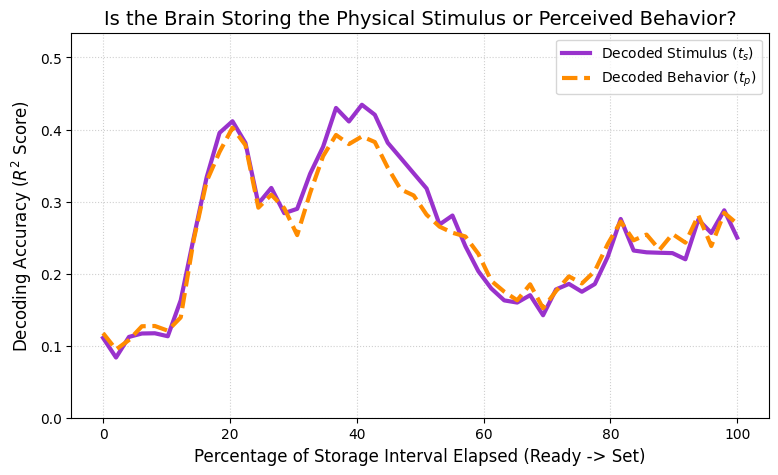

In [24]:
# Array to hold R2 scores for predicting behavioral production (tp)
time_resolved_r2_tp = []
y_behavior = np.array(clean_trials['tp'])

for t in range(num_standard_bins):
    states_at_t = []
    for trial_data in trial_matrices:
        if trial_data.shape[0] < 2:
            states_at_t.append(np.zeros(train_matrix.shape[1]))
            continue
        original_time = np.linspace(0, 1, trial_data.shape[0])
        f = interp1d(original_time, trial_data, axis=0, kind='linear', fill_value="extrapolate")
        states_at_t.append(f(standard_time[t]))
        
    X_t = np.array(states_at_t)
    
    # Train decoder to predict the behavioral response 'tp'
    decoder_t = Ridge(alpha=1.0)
    decoder_t.fit(X_t, y_behavior)
    preds_t = decoder_t.predict(X_t)
    
    time_resolved_r2_tp.append(r2_score(y_behavior, preds_t))

# Plot both the physical stimulus tracking and behavioral tracking side-by-side
plt.figure(figsize=(9, 5))
plt.plot(standard_time * 100, time_resolved_r2, color='darkorchid', linewidth=3, label="Decoded Stimulus ($t_s$)")
plt.plot(standard_time * 100, time_resolved_r2_tp, color='darkorange', linewidth=3, linestyle='--', label="Decoded Behavior ($t_p$)")

plt.title("Is the Brain Storing the Physical Stimulus or Perceived Behavior?", fontsize=14)
plt.xlabel("Percentage of Storage Interval Elapsed (Ready -> Set)", fontsize=12)
plt.ylabel("Decoding Accuracy ($R^2$ Score)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, max(max(time_resolved_r2), max(time_resolved_r2_tp)) + 0.1)
plt.show()

In [26]:
# Look at the decoder weights at the peak of decoding (~40% into the trial, which is bin index 20)
peak_bin = 20

# Re-train the decoder at that peak bin to get the coefficients
states_at_peak = []
for trial_data in trial_matrices:
    if trial_data.shape[0] < 2:
        states_at_peak.append(np.zeros(train_matrix.shape[1]))
        continue
    original_time = np.linspace(0, 1, trial_data.shape[0])
    f = interp1d(original_time, trial_data, axis=0, kind='linear', fill_value="extrapolate")
    states_at_peak.append(f(standard_time[peak_bin]))

peak_decoder = Ridge(alpha=1.0)
peak_decoder.fit(np.array(states_at_peak), y_true)

# Find the absolute largest weights (coefficients)
abs_weights = np.abs(peak_decoder.coef_)
top_units = np.argsort(abs_weights)[::-1][:5]

print("Top 5 Timing-Encoding Neurons")
for rank, unit_idx in enumerate(top_units):
    print(f"Rank {rank+1}: Unit {unit_idx} (Weight magnitude: {abs_weights[unit_idx]:.3f})")

Top 5 Timing-Encoding Neurons
Rank 1: Unit 38 (Weight magnitude: 117.722)
Rank 2: Unit 37 (Weight magnitude: 104.177)
Rank 3: Unit 40 (Weight magnitude: 98.389)
Rank 4: Unit 51 (Weight magnitude: 96.249)
Rank 5: Unit 42 (Weight magnitude: 91.454)


In [27]:
# Lists to hold the production phase neural data and actual production times (tp)
production_matrices = []
production_tp = []

for idx, row in clean_trials.iterrows():
    # Define our window of interest: from Set cue to Go response
    t_start = row['set_time']
    t_end = row['go_time']
    
    # Find the corresponding global bins
    bin_start = np.searchsorted(bin_edges, t_start) - 1
    bin_end = np.searchsorted(bin_edges, t_end)
    
    trial_data = train_matrix[bin_start:bin_end, :]
    
    production_matrices.append(trial_data)
    production_tp.append(row['tp'])

# Calculate time-warped averages for the production phase
production_averages = {}
for ts_val in unique_ts:
    matching_trials = [production_matrices[i] for i in range(len(production_tp)) if trial_ts[i] == ts_val]
    
    warped_trials = []
    for trial_data in matching_trials:
        if trial_data.shape[0] < 2:
            continue
        original_time = np.linspace(0, 1, trial_data.shape[0])
        f = interp1d(original_time, trial_data, axis=0, kind='linear', fill_value="extrapolate")
        warped_trials.append(f(standard_time))
        
    production_averages[ts_val] = np.mean(warped_trials, axis=0)

print(f"Successfully processed the production phase for {len(production_matrices)} trials!")
print(f"Example - Production Trial 0 data shape (Bins x Units): {production_matrices[0].shape}")

Successfully processed the production phase for 720 trials!
Example - Production Trial 0 data shape (Bins x Units): (42, 54)


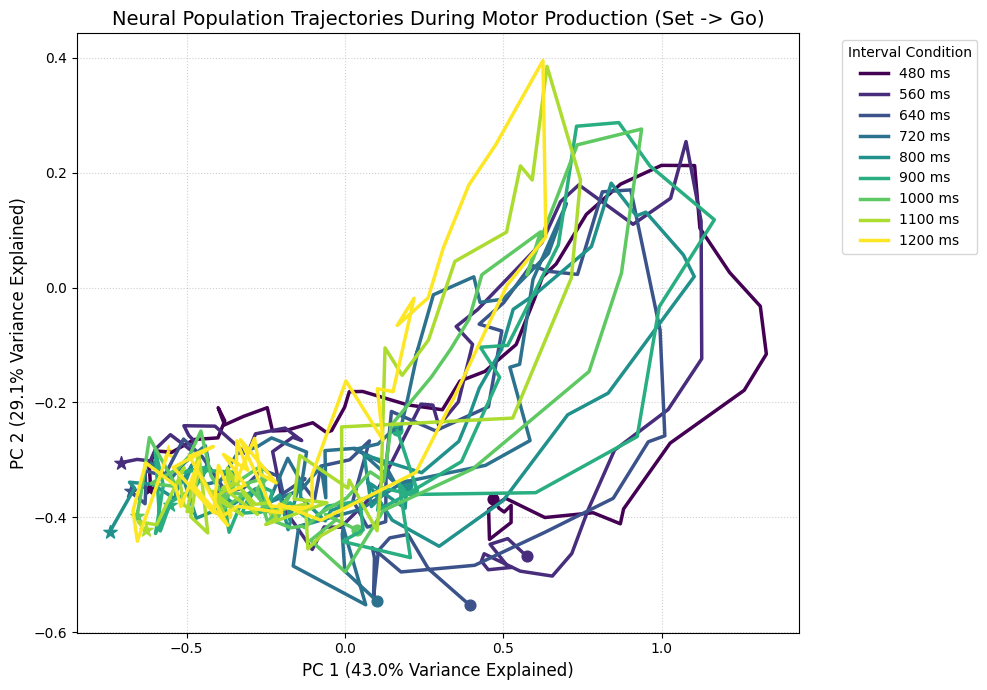

In [28]:
plt.figure(figsize=(10, 7))

# Use the same color scheme (viridis) from shortest to longest interval
for i, ts_val in enumerate(unique_ts):
    # Project this specific condition's production average into the same PCA space
    unwarped_prod_trajectory = production_averages[ts_val]
    projected_prod = pca.transform(unwarped_prod_trajectory)
    
    # Plot the execution trajectory across the 50 standardized time bins
    plt.plot(projected_prod[:, 0], projected_prod[:, 1], color=colors[i], linewidth=2.5, linestyle='-', label=f'{int(ts_val)} ms')
    
    # Mark the start (Set cue) with a circle and the end (Go action) with a star
    plt.scatter(projected_prod[0, 0], projected_prod[0, 1], color=colors[i], marker='o', s=60)
    plt.scatter(projected_prod[-1, 0], projected_prod[-1, 1], color=colors[i], marker='*', s=100)

plt.title("Neural Population Trajectories During Motor Production (Set -> Go)", fontsize=14)
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance Explained)", fontsize=12)
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance Explained)", fontsize=12)
plt.legend(title="Interval Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

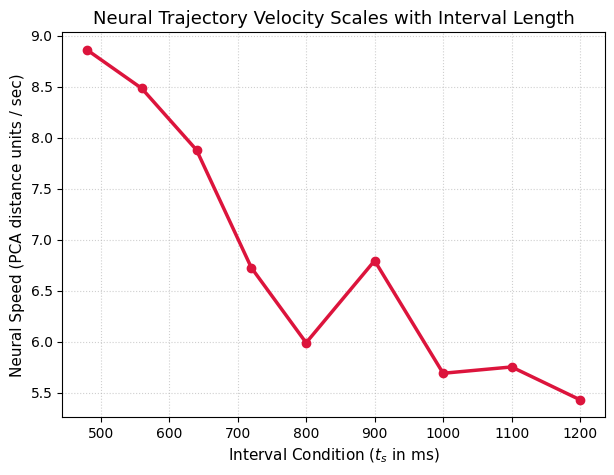

In [29]:
# Array to hold the average neural speed for each interval condition
neural_speeds = []

for ts_val in unique_ts:
    # Get the PCA-projected trajectory for this condition during production
    proj_prod = pca.transform(production_averages[ts_val])
    
    # Calculate the Euclidean distance between consecutive points in PCA space
    distances = np.sqrt(np.sum(np.diff(proj_prod, axis=0)**2, axis=1))
    
    # The actual physical time step per bin for this condition (in seconds)
    # Total time is ts_val / 1000, divided across our 50 standard bins
    dt = (ts_val / 1000.0) / num_standard_bins
    
    # Speed = Distance / Time
    speeds = distances / dt
    neural_speeds.append(np.mean(speeds))

# Plot the relationship between the Interval and Neural Velocity
plt.figure(figsize=(7, 5))
plt.plot(unique_ts, neural_speeds, color='crimson', marker='o', linewidth=2.5)
plt.title("Neural Trajectory Velocity Scales with Interval Length", fontsize=13)
plt.xlabel("Interval Condition ($t_s$ in ms)", fontsize=11)
plt.ylabel("Neural Speed (PCA distance units / sec)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

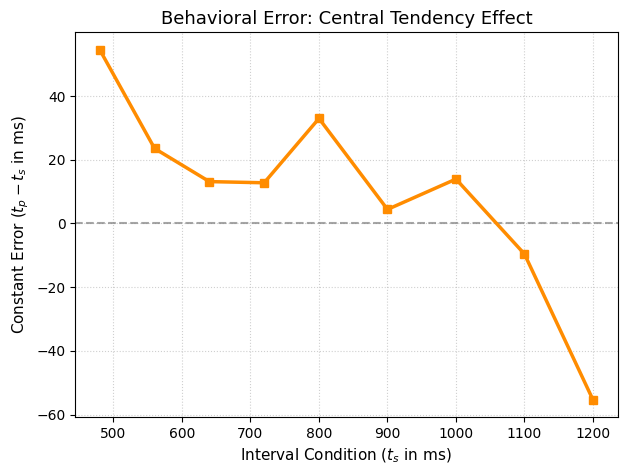

In [30]:
# Calculate the mean behavioral production (tp) for each unique stimulus interval (ts)
behavioral_means = []
behavioral_errors = []

for ts_val in unique_ts:
    # Get the actual 'tp' values for this specific interval
    matching_tps = clean_trials[clean_trials['ts'] == ts_val]['tp']
    mean_tp = np.mean(matching_tps)
    
    behavioral_means.append(mean_tp)
    # Error = Perceived/Produced Time - True Physical Time
    behavioral_errors.append(mean_tp - ts_val)

# Plot the behavioral errors
plt.figure(figsize=(7, 5))
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
plt.plot(unique_ts, behavioral_errors, color='darkorange', marker='s', linewidth=2.5)
plt.title("Behavioral Error: Central Tendency Effect", fontsize=13)
plt.xlabel("Interval Condition ($t_s$ in ms)", fontsize=11)
plt.ylabel("Constant Error ($t_p - t_s$ in ms)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()